In [1]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

# -------------------------------------------------
# 0. 기본 설정
# -------------------------------------------------
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')  # 코랩 한글 폰트

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/영천의미학"

# 파일 경로
GRID_SHP_PATH = BASE_DIR + "/grid_마마_1K.shp"
BORDER_SHP_PATH = BASE_DIR + "/bnd_sigungu_37070_2025_2Q.shp"
FIRE_FINAL_PATH = BASE_DIR + "/fire_final.csv"

# -------------------------------------------------
# 1. 데이터 읽기
# -------------------------------------------------
# fire_final.csv 읽기
fire_final = pd.read_csv(FIRE_FINAL_PATH, encoding="utf-8-sig")

# 격자 shp 읽기
grid = gpd.read_file(GRID_SHP_PATH)

# 경계 shp 읽기
bord = gpd.read_file(BORDER_SHP_PATH)

# -------------------------------------------------
# 2. 좌표계 통일
# -------------------------------------------------
grid = grid.to_crs(epsg=5179)
bord = bord.to_crs(epsg=5179)

# -------------------------------------------------
# 3. 영천시 경계만 추출하고 격자 clip
# -------------------------------------------------
yeongcheon = bord[bord["SIGUNGU_NM"] == "영천시"].copy()

# 영천시 기준으로 격자 자르기
grid_clip = gpd.clip(grid, yeongcheon)

# shapefile의 격자 코드 컬럼명을 통일
# 원래 컬럼명이 GRID_CD라고 가정
grid_clip = grid_clip.rename(columns={"GRID_CD": "Grid_Name"})

# 문자열 공백 제거
grid_clip["Grid_Name"] = grid_clip["Grid_Name"].astype(str).str.strip()
fire_final["Grid_Name"] = fire_final["Grid_Name"].astype(str).str.strip()

# -------------------------------------------------
# 4. fire_final과 격자 merge
# -------------------------------------------------
fire_map = grid_clip.merge(
    fire_final,
    on="Grid_Name",
    how="left"
)

print("merge 후 행 수:", len(fire_map))
display(fire_map[[
    "Grid_Name",
    "best_fire_name",
    "best_fire_final_dist_m",
    "best_fire_final_duration_min"
]].head())

# -------------------------------------------------
# 5. 시각화할 컬럼 선택
# -------------------------------------------------
# 시간 히트맵을 보고 싶으면 아래 컬럼 사용
target_col = "best_fire_final_duration_min"
title_name = "소방시설 접근 소요시간(분)"

def draw_fire_heatmap(fire_map, yeongcheon, target_col, title_name, cmap="OrRd"):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    fire_map.plot(
        column=target_col,
        ax=ax,
        cmap=cmap,
        linewidth=0.2,
        edgecolor="gray",
        legend=True,
        missing_kwds={
            "color": "lightgrey",
            "label": "데이터 없음"
        }
    )

    yeongcheon.boundary.plot(ax=ax, color="black", linewidth=1.5)

    ax.set_title(f"영천시 격자별 {title_name} 히트맵", fontsize=18, pad=20)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

merge 후 행 수: 1014


,Grid_Name,best_fire_name,best_fire_final_dist_m,best_fire_final_duration_min
0,마마2461,NaN,NaN,NaN
1,마마2264,금호119안전센터,7917.0,11.75
2,마마2462,금호119안전센터,8903.0,17.90
3,마마2463,금호119안전센터,8343.0,15.80
4,마마2364,금호119안전센터,10109.0,17.05


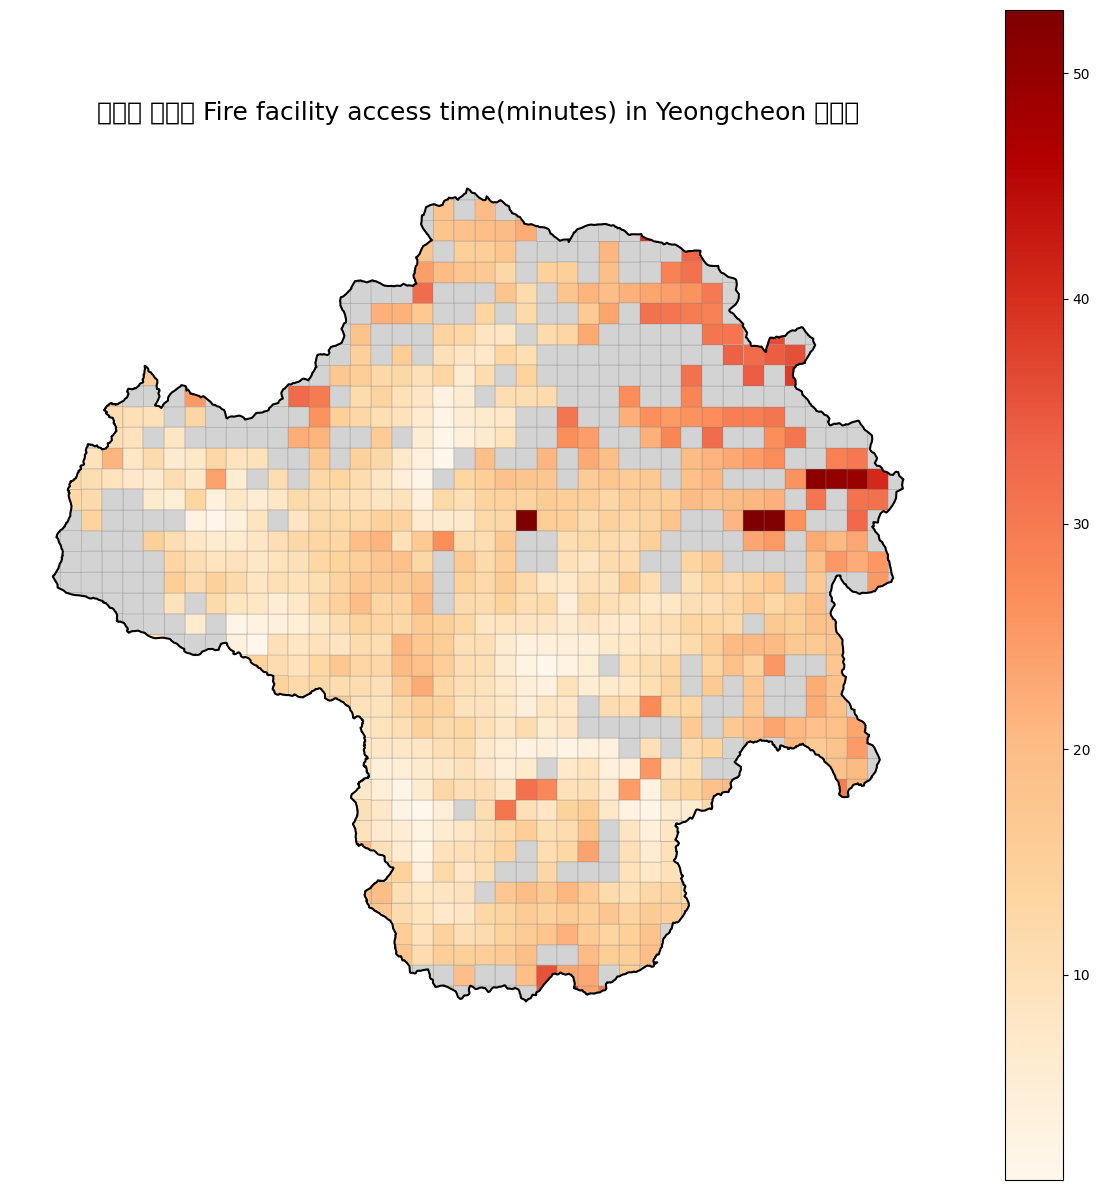

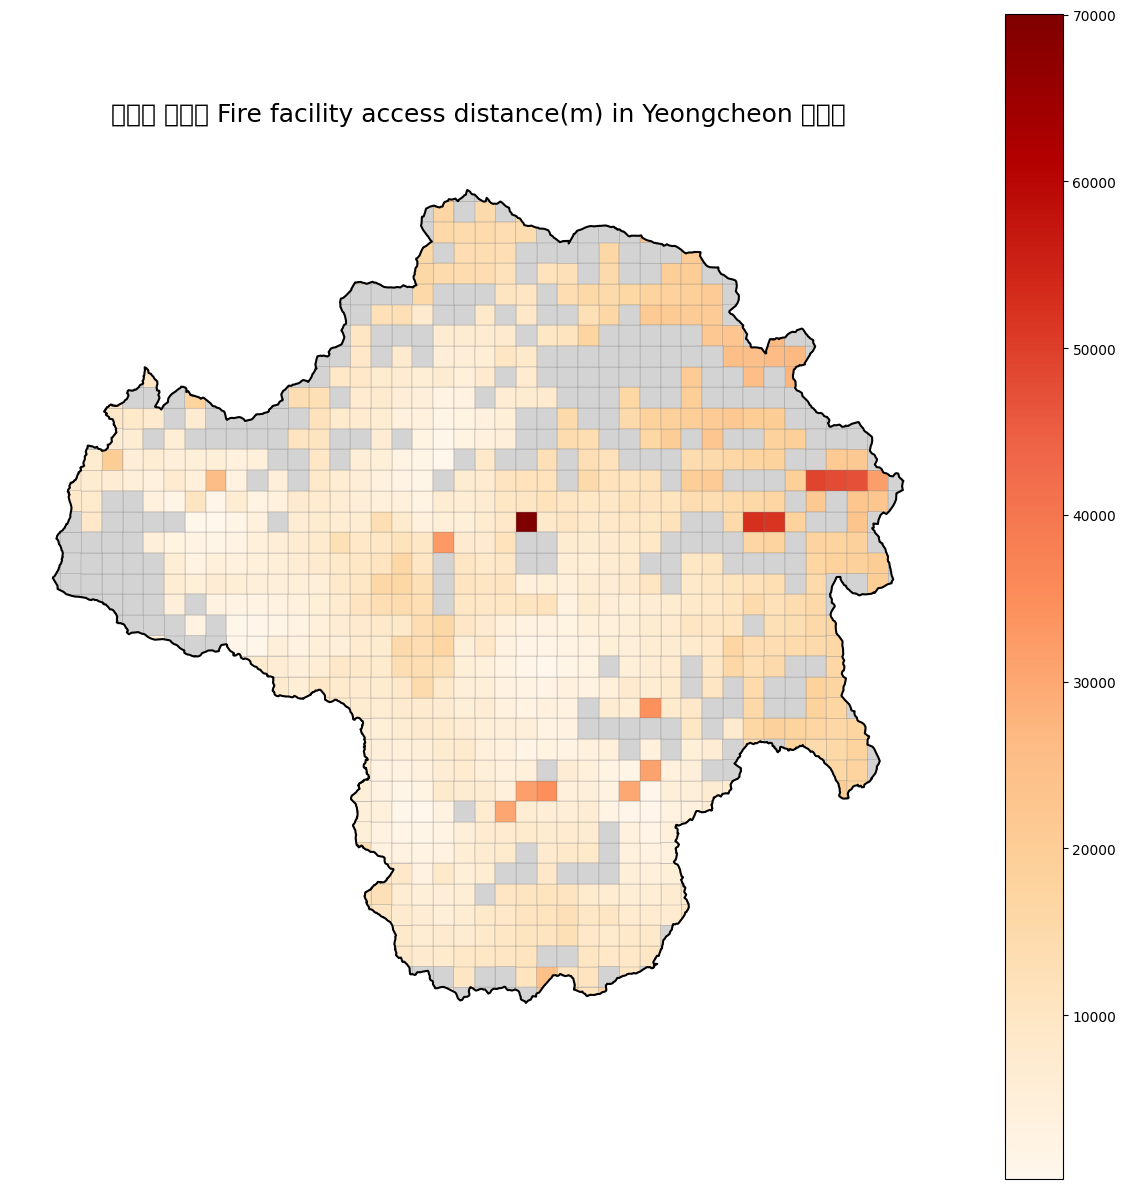

In [10]:
# 1) 시간 히트맵
draw_fire_heatmap(
    fire_map=fire_map,
    yeongcheon=yeongcheon,
    target_col="best_fire_final_duration_min",
    title_name="Fire facility access time(minutes) in Yeongcheon"
)

# 2) 거리 히트맵
draw_fire_heatmap(
    fire_map=fire_map,
    yeongcheon=yeongcheon,
    target_col="best_fire_final_dist_m",
    title_name="Fire facility access distance(m) in Yeongcheon"
)

In [18]:
target_col = "best_fire_final_duration_min"

# 값이 있는 격자만 대상으로 큰 값 순서대로 후보 추출
outlier_candidates = fire_map[
    fire_map[target_col].notna()
].copy()

outlier_candidates = outlier_candidates.sort_values(
    target_col,
    ascending=False
).head(20)

display(outlier_candidates[[
    "Grid_Name",
    "best_fire_name",
    "best_fire_final_dist_m",
    "best_fire_final_duration_min"
]])

,Grid_Name,best_fire_name,best_fire_final_dist_m,best_fire_final_duration_min
740,마마4183,동부119안전센터,52735.0,52.800000
675,마마3083,화남119지역대,70046.0,52.783333
728,마마4283,동부119안전센터,51888.0,52.316667
902,마마4485,동부119안전센터,49180.0,51.050000
903,마마4585,동부119안전센터,48178.0,50.316667
901,마마4685,동부119안전센터,47178.0,49.366667
911,마마4785,동부119안전센터,32064.0,40.700000
999,마마3697,화남119지역대,23016.0,39.283333
922,마마4390,동부119안전센터,27543.0,38.350000
119,마마3260,영천소방서 북안119지역대,19895.0,38.016667


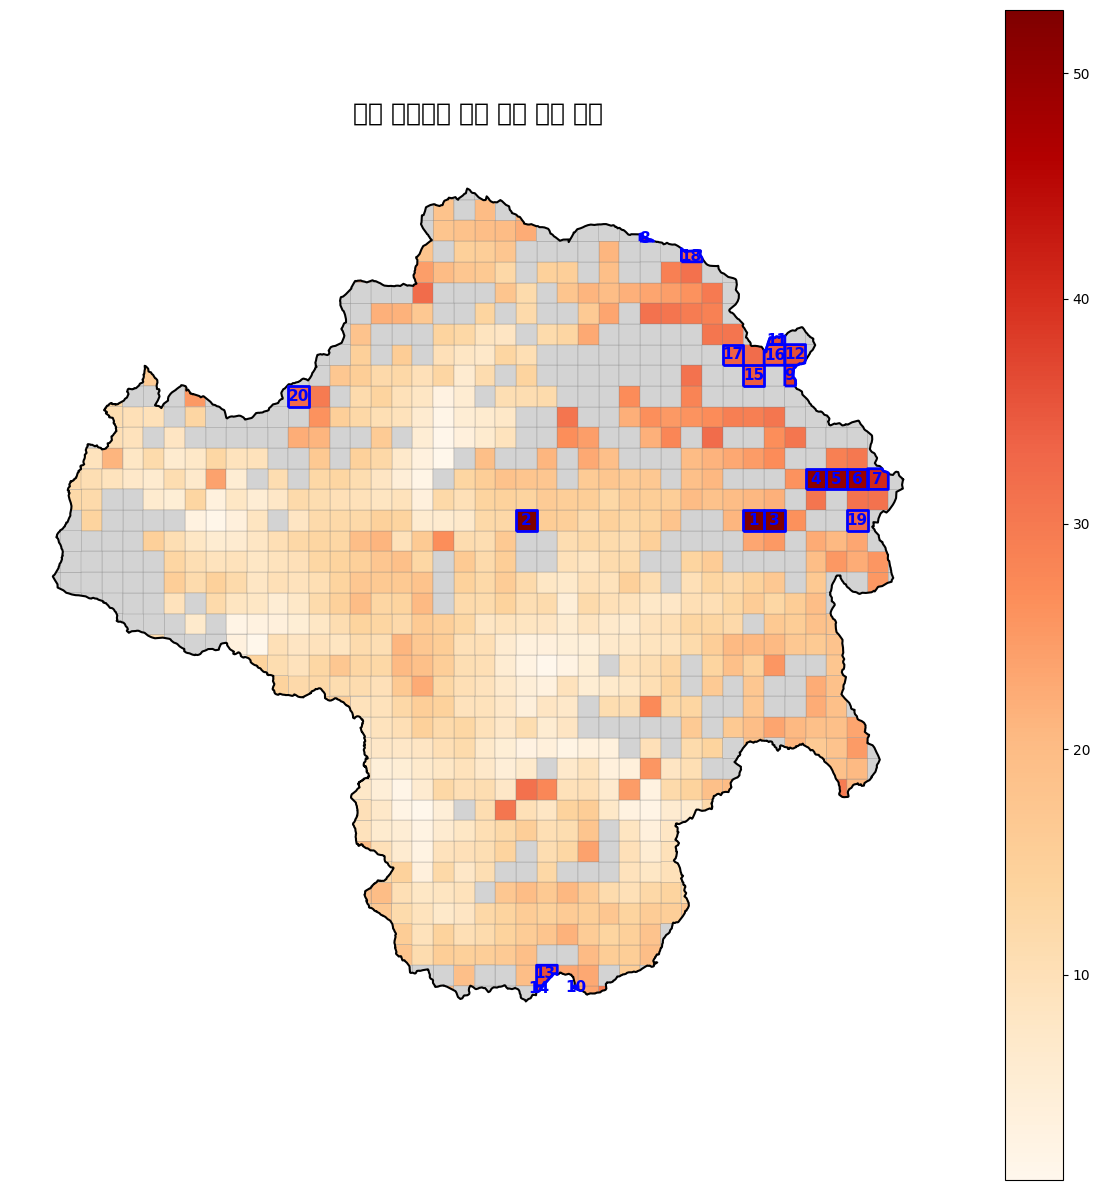

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# 전체 히트맵
fire_map.plot(
    column=target_col,
    ax=ax,
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "데이터 없음"
    }
)

# 영천시 경계
yeongcheon.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

# 후보 격자 테두리 강조
outlier_candidates.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=2
)

# 후보 격자 중심에 번호 표시
for num, (idx, row) in enumerate(outlier_candidates.iterrows(), start=1):
    c = row.geometry.centroid
    ax.text(
        c.x,
        c.y,
        str(num),
        fontsize=11,
        color="blue",
        weight="bold",
        ha="center",
        va="center"
    )

ax.set_title("소방 접근시간 상위 후보 격자 표시", fontsize=18, pad=20)
ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
candidate_table = outlier_candidates[[
    "Grid_Name",
    "best_fire_name",
    "best_fire_final_dist_m",
    "best_fire_final_duration_min"
]].copy()

candidate_table.insert(0, "map_no", range(1, len(candidate_table) + 1))

display(candidate_table)

,map_no,Grid_Name,best_fire_name,best_fire_final_dist_m,best_fire_final_duration_min
740,1,마마4183,동부119안전센터,52735.0,52.800000
675,2,마마3083,화남119지역대,70046.0,52.783333
728,3,마마4283,동부119안전센터,51888.0,52.316667
902,4,마마4485,동부119안전센터,49180.0,51.050000
903,5,마마4585,동부119안전센터,48178.0,50.316667
901,6,마마4685,동부119안전센터,47178.0,49.366667
911,7,마마4785,동부119안전센터,32064.0,40.700000
999,8,마마3697,화남119지역대,23016.0,39.283333
922,9,마마4390,동부119안전센터,27543.0,38.350000
119,10,마마3260,영천소방서 북안119지역대,19895.0,38.016667


In [21]:
manual_outlier_grids = [
    "마마3083"
]
import numpy as np

def smooth_selected_grids_by_neighbors(
    gdf,
    grid_names,
    value_col,
    output_col,
    neighbor_radius=1500,
    method="median"
):
    """
    사용자가 직접 지정한 Grid_Name만 주변 격자 값으로 대체하는 함수.

    gdf:
        fire_map 같은 GeoDataFrame

    grid_names:
        스무딩할 Grid_Name 리스트

    value_col:
        원본 값 컬럼명

    output_col:
        스무딩 결과를 저장할 새 컬럼명

    neighbor_radius:
        주변 격자 탐색 반경.
        1km 격자 기준으로 1500m 정도면 주변 8칸을 포함함.

    method:
        "median" 또는 "mean"
    """

    result = gdf.copy()

    # 원본 값은 보존하고, 시각화용 컬럼만 따로 만듦
    result[output_col] = result[value_col]

    smooth_log = []

    for grid_name in grid_names:
        target_rows = result[result["Grid_Name"] == grid_name]

        if len(target_rows) == 0:
            print(f"[경고] Grid_Name={grid_name} 을 찾지 못함")
            continue

        target_idx = target_rows.index[0]
        target_geom = result.loc[target_idx, "geometry"]
        target_centroid = target_geom.centroid
        original_value = result.loc[target_idx, value_col]

        # 모든 격자 중심점과 대상 격자 중심점 사이 거리 계산
        centroid_dist = result.geometry.centroid.distance(target_centroid)

        # 자기 자신 제외 + 주변 반경 이내 + 값이 있는 격자
        neighbors = result[
            (centroid_dist > 0) &
            (centroid_dist <= neighbor_radius) &
            (result[value_col].notna())
        ].copy()

        if len(neighbors) == 0:
            print(f"[경고] Grid_Name={grid_name} 주변 격자를 찾지 못함")
            continue

        if method == "median":
            new_value = neighbors[value_col].median()
        elif method == "mean":
            new_value = neighbors[value_col].mean()
        else:
            raise ValueError("method는 'median' 또는 'mean'만 가능")

        result.loc[target_idx, output_col] = new_value

        smooth_log.append({
            "Grid_Name": grid_name,
            "original_value": original_value,
            "smoothed_value": new_value,
            "neighbor_count": len(neighbors),
            "neighbor_min": neighbors[value_col].min(),
            "neighbor_median": neighbors[value_col].median(),
            "neighbor_max": neighbors[value_col].max()
        })

    smooth_log_df = pd.DataFrame(smooth_log)

    return result, smooth_log_df

In [22]:
fire_map_manual_smooth, smooth_log = smooth_selected_grids_by_neighbors(
    gdf=fire_map,
    grid_names=manual_outlier_grids,
    value_col="best_fire_final_duration_min",
    output_col="fire_duration_visual",
    neighbor_radius=1500,
    method="median"
)

display(smooth_log)

,Grid_Name,original_value,smoothed_value,neighbor_count,neighbor_min,neighbor_median,neighbor_max
0,마마3083,52.783333,15.116667,6,12.5,15.116667,16.9


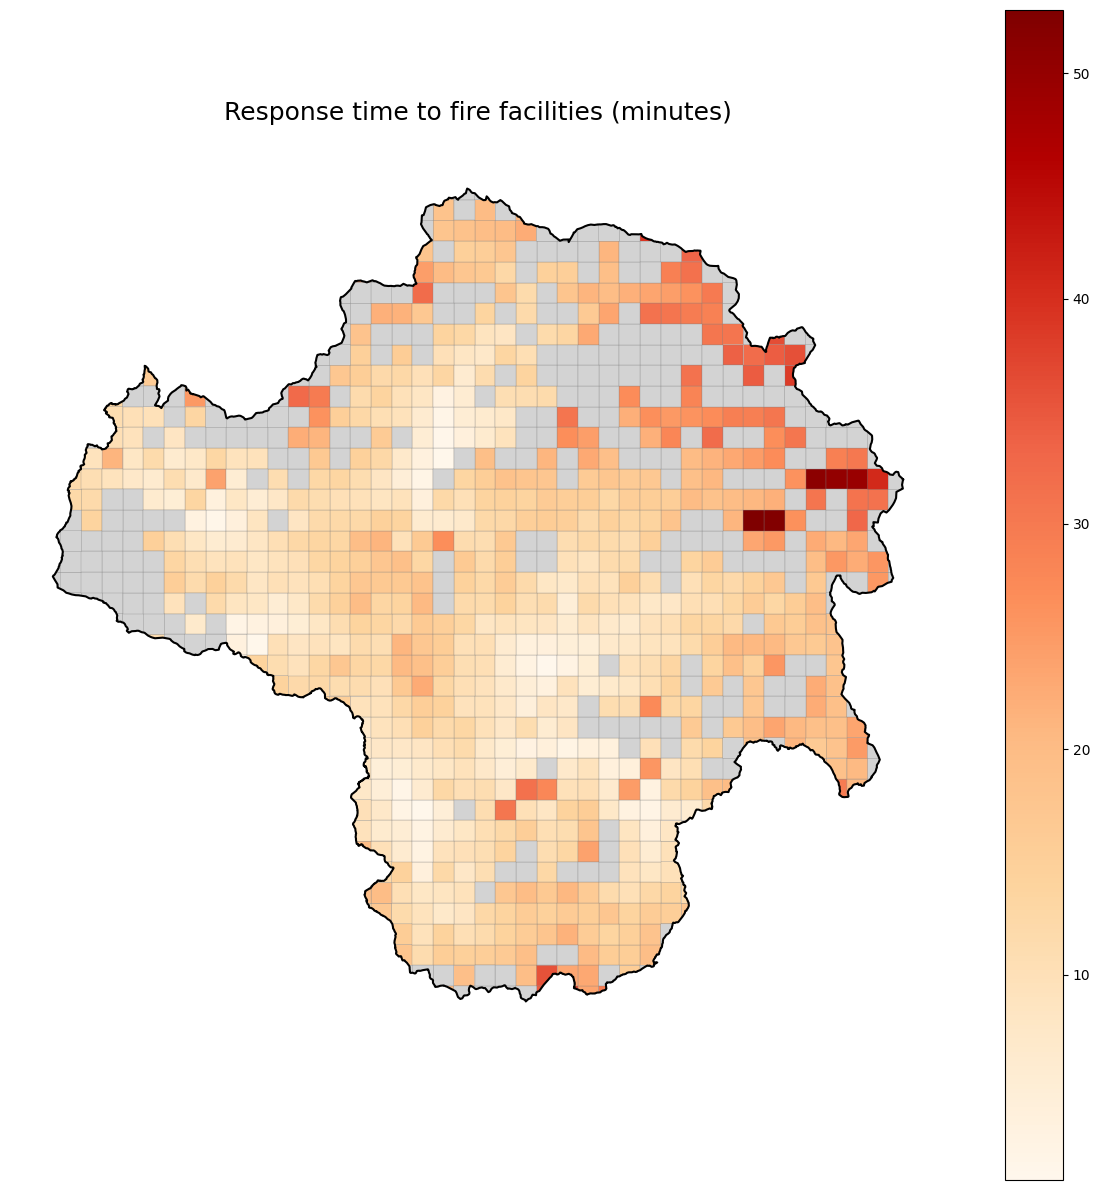

In [24]:
fig, ax = plt.subplots(figsize=(12, 12))

fire_map_manual_smooth.plot(
    column="fire_duration_visual",
    ax=ax,
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "데이터 없음"
    }
)

yeongcheon.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)


ax.set_title("Response time to fire facilities (minutes)", fontsize=18, pad=20)
ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
compare_cols = [
    "Grid_Name",
    "best_fire_name",
    "best_fire_final_dist_m",
    "best_fire_final_duration_min",
    "fire_duration_visual"
]

display(
    fire_map_manual_smooth[
        fire_map_manual_smooth["Grid_Name"].isin(manual_outlier_grids)
    ][compare_cols]
)

,Grid_Name,best_fire_name,best_fire_final_dist_m,best_fire_final_duration_min,fire_duration_visual
675,마마3083,화남119지역대,70046.0,52.783333,15.116667
